Rohdaten:


,kunden_id,name,kunden_alter,umsatz,region,produkt
0,1,Max Mustermann,35.0,1500.50,Bayern,Laptop
1,2,Anna Schmidt,NaN,2300.75,Baden-Württemberg,NaN
2,3,Peter Müller,42.0,1800.00,Bayern,Laptop
3,4,Max Mustermann,35.0,1500.50,Bayern,Laptop
4,5,Lisa Bauer,28.0,900.25,Hessen,Tablet
5,6,Thomas Weber,50.0,3200.00,NRW,NaN
6,7,NaN,31.0,1200.00,Bayern,Monitor



Daten nach Bereinigung:


,kunden_id,name,kunden_alter,umsatz,region,produkt,alter
0,1,Max Mustermann,35.0,1500.50,Bayern,Laptop,35
1,2,Anna Schmidt,NaN,2300.75,Baden-Württemberg,Unbekannt,35
2,3,Peter Müller,42.0,1800.00,Bayern,Laptop,42
3,4,Max Mustermann,35.0,1500.50,Bayern,Laptop,35
4,5,Lisa Bauer,28.0,900.25,Hessen,Tablet,28
5,6,Thomas Weber,50.0,3200.00,NRW,Unbekannt,50
6,7,Unbekannt,31.0,1200.00,Bayern,Monitor,31



Umsatz nach Region:


region
Bayern               6001.00
NRW                  3200.00
Baden-Württemberg    2300.75
Hessen                900.25
Name: umsatz, dtype: float64


Häufigste Produkte:


produkt
Laptop       3
Unbekannt    2
Tablet       1
Monitor      1
Name: count, dtype: int64


Durchschnittsalter der Kund:innen: 36.8 Jahre


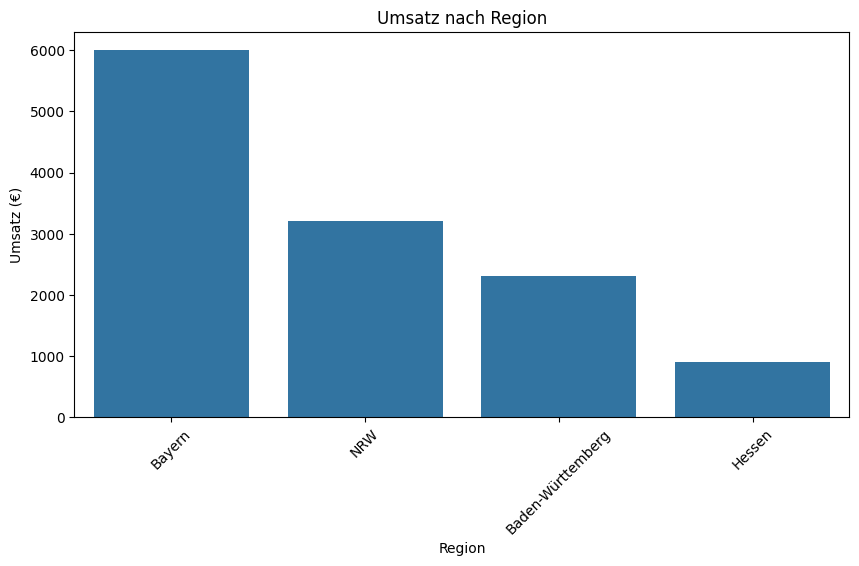

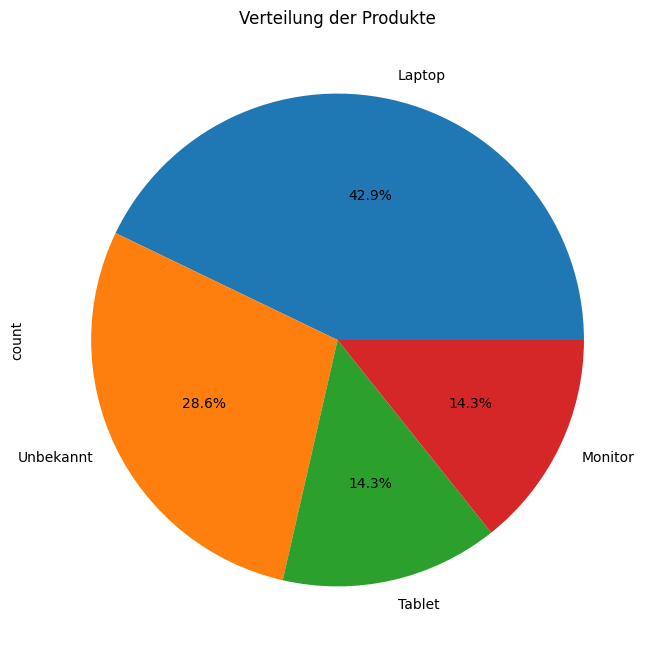

In [4]:
# %% [Markdown]
"""
# Datenbereinigung & Analyse mit Pandas
**Ziel:** Rohdaten laden, bereinigen, analysieren und visualisieren.
**Daten:** Fiktive Kundendaten (kunden.csv)
"""

# %% [Code]
# Bibliotheken importieren
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %% [Markdown]
"""
## 1. Daten laden
"""

# %% [Code]
# CSV-Datei einlesen
df = pd.read_csv("kunden.csv")
print("Rohdaten:")
display(df)

# %% [Markdown]
"""
## 2. Daten bereinigen
- Fehlende Werte behandeln
- Duplikate entfernen
- Datentypen korrigieren
"""

# %% [Code]
# Fehlende Werte in 'name' mit 'Unbekannt' füllen
df["name"] = df["name"].fillna("Unbekannt")

# Fehlende Werte in 'produkt' mit 'Unbekannt' füllen
df["produkt"] = df["produkt"].fillna("Unbekannt")

# Duplikate entfernen
df = df.drop_duplicates()

# 'alter' in Integer umwandeln (fehlende Werte mit Median füllen)
df["alter"] = pd.to_numeric(df["kunden_alter"], errors="coerce")
df["alter"] = df["kunden_alter"].fillna(df["kunden_alter"].median()).astype(int)

# 'umsatz' in Float umwandeln
df["umsatz"] = pd.to_numeric(df["umsatz"], errors="coerce")

print("\nDaten nach Bereinigung:")
display(df)

# %% [Markdown]
"""
## 3. Daten analysieren
- Umsatz nach Region
- Häufigste Produkte
- Durchschnittsalter der Kund:innen
"""

# %% [Code]
# Umsatz nach Region
umsatz_region = df.groupby("region")["umsatz"].sum().sort_values(ascending=False)
print("\nUmsatz nach Region:")
display(umsatz_region)

# Häufigste Produkte
produkt_häufigkeit = df["produkt"].value_counts()
print("\nHäufigste Produkte:")
display(produkt_häufigkeit)

# Durchschnittsalter
durchschnittsalter = df["kunden_alter"].mean()
print(f"\nDurchschnittsalter der Kund:innen: {durchschnittsalter:.1f} Jahre")

# %% [Markdown]
"""
## 4. Visualisierung
"""

# %% [Code]
# Umsatz nach Region als Balkendiagramm
plt.figure(figsize=(10, 5))
sns.barplot(x=umsatz_region.index, y=umsatz_region.values)
plt.title("Umsatz nach Region")
plt.xlabel("Region")
plt.ylabel("Umsatz (€)")
plt.xticks(rotation=45)
plt.show()

# Produktverteilung als Kreisdiagramm
plt.figure(figsize=(8, 8))
produkt_häufigkeit.plot.pie(autopct="%1.1f%%")
plt.title("Verteilung der Produkte")
plt.show()

In [5]:
# %% [Markdown]
"""
## 5. Daten aus API laden (Bonus)
Daten von [JSONPlaceholder](https://jsonplaceholder.typicode.com/) laden und in DataFrame umwandeln.
"""

# %% [Code]
import requests

# API-Aufruf: Beispiel-Daten (Posts)
api_url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(api_url)
api_data = response.json()

# In DataFrame umwandeln
df_api = pd.DataFrame(api_data)
print("\nDaten von API:")
display(df_api.head())

# %% [Markdown]
"""
## 6. Daten in SQLite-Datenbank speichern
"""

# %% [Code]
import sqlite3

# SQLite-Datenbank erstellen
conn = sqlite3.connect("kunden_daten.db")
cursor = conn.cursor()

# Tabelle für Kundendaten erstellen
cursor.execute("""
CREATE TABLE IF NOT EXISTS kunden (
    kunden_id INTEGER PRIMARY KEY,
    name TEXT,
    kunden_alter INTEGER,
    umsatz REAL,
    region TEXT,
    produkt TEXT
)
""")

# Daten aus DataFrame in SQLite schreiben
df.to_sql("kunden", conn, if_exists="replace", index=False)

# Tabelle für API-Daten erstellen
cursor.execute("""
CREATE TABLE IF NOT EXISTS api_posts (
    userId INTEGER,
    id INTEGER PRIMARY KEY,
    title TEXT,
    body TEXT
)
""")

# API-Daten in SQLite schreiben
df_api.to_sql("api_posts", conn, if_exists="replace", index=False)

# Verbindung schließen
conn.close()
print("\nDaten erfolgreich in SQLite-Datenbank gespeichert!")


Daten von API:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...



Daten erfolgreich in SQLite-Datenbank gespeichert!
